<a href="https://colab.research.google.com/github/sreenandinisreenivasan3-sree/ML-project/blob/main/Sreenandini_S_Exit_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
data=pd.read_csv('/content/customer_churn.csv')

In [39]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0.0,Yes,No,1.0,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0.0,No,No,34.0,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0.0,No,No,2.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0.0,No,No,45.0,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0.0,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [40]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [41]:
data.dtypes

,0
customerID,object
gender,object
SeniorCitizen,float64
Partner,object
Dependents,object
tenure,float64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [42]:
data.shape

(7043, 21)

In [43]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7036.000000,7030.000000,7027.000000
mean,0.162024,32.367568,64.757855
std,0.368499,24.560644,30.091845
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [44]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,7
Partner,0
Dependents,0
tenure,13
PhoneService,13
MultipleLines,13
InternetService,37
OnlineSecurity,15


In [45]:
data['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [46]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors='coerce')

In [47]:
data= data.drop('customerID', axis=1)

In [48]:
num_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [49]:
data[num_cols] = data[num_cols].fillna(data[num_cols].median())

In [50]:
cate_cols=data.select_dtypes(include=['object']).columns.tolist()

In [51]:
for col in cate_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

In [52]:
data.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


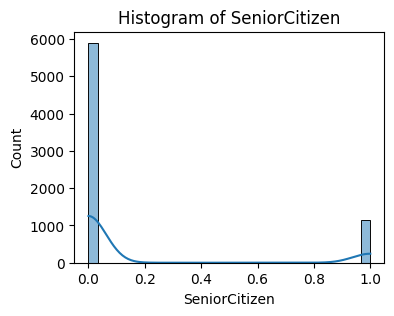

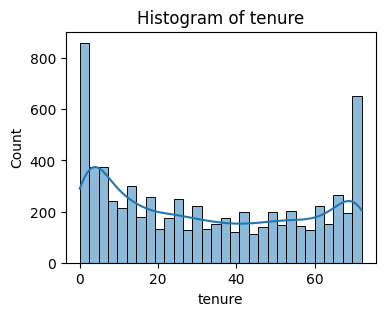

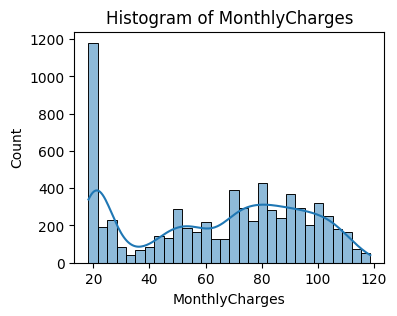

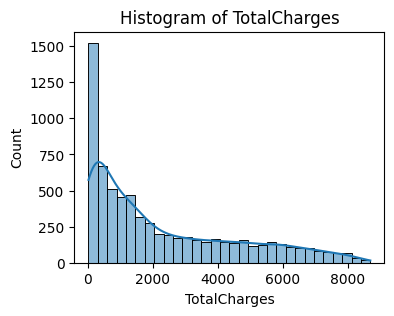

In [53]:
for col in num_cols:
  plt.figure(figsize=(4,3))
  sns.histplot(data[col], bins=30, kde=True)
  plt.title(f'Histogram of {col}')
  plt.show()

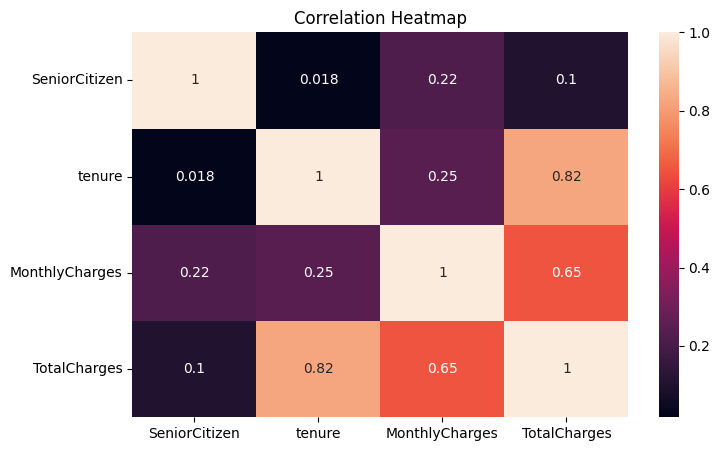

In [54]:
plt.figure(figsize=(8,5))
sns.heatmap(data[num_cols].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

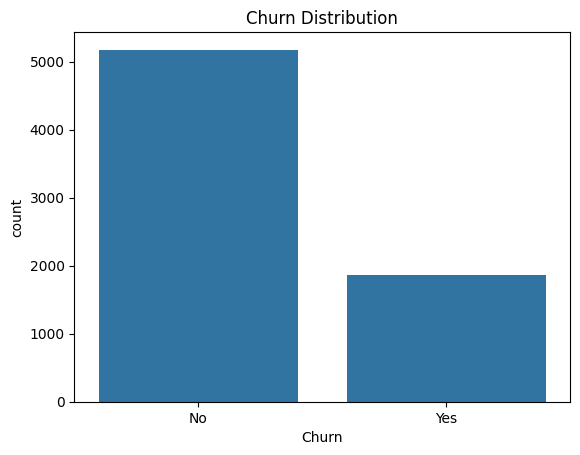

In [55]:
sns.countplot(x='Churn', data=data)
plt.title("Churn Distribution")
plt.show()

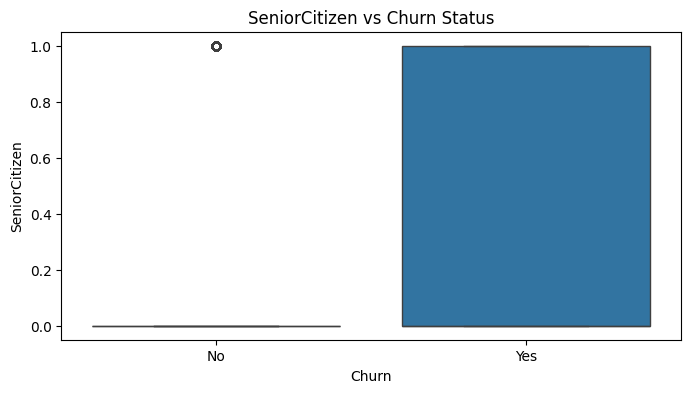

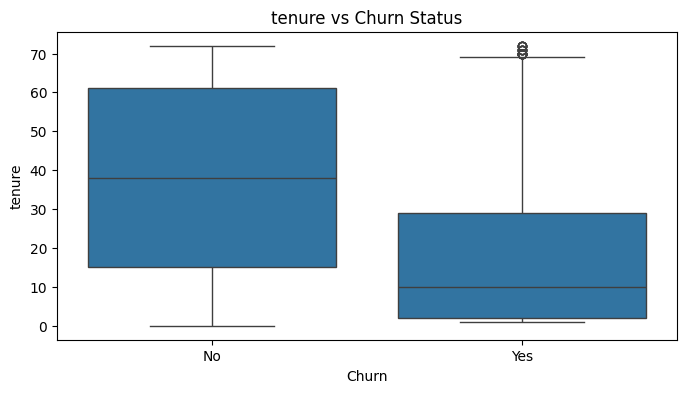

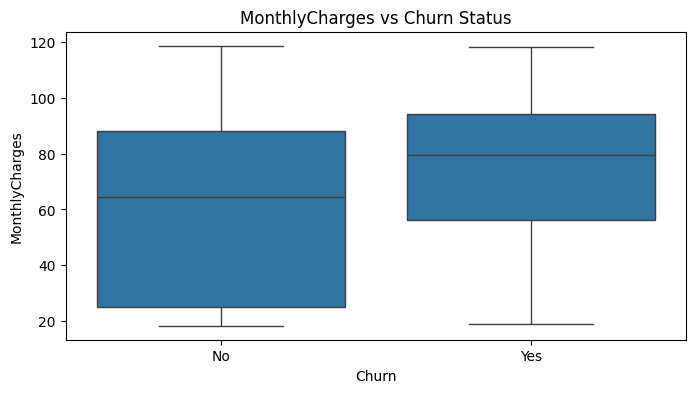

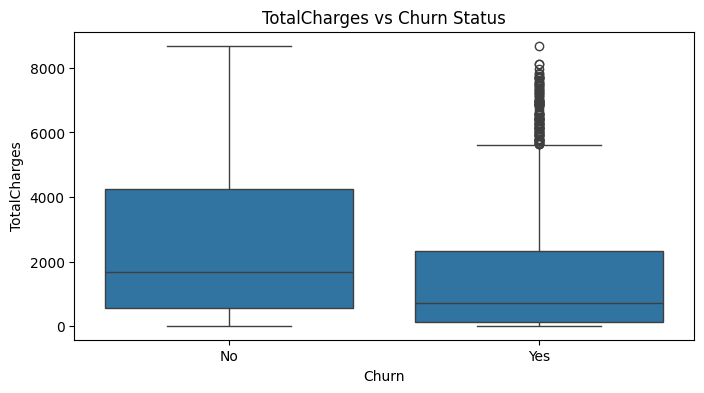

In [56]:
for col in num_cols:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x="Churn", y=col, data=data)
        plt.title(f"{col} vs Churn Status")
        plt.show()

In [57]:
col_to_fix = ['TotalCharges', 'MonthlyCharges', 'tenure']
Q1 = data[col_to_fix].quantile(0.25)
Q3 = data[col_to_fix].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data_cleaned = data.copy()
data_cleaned[col_to_fix] = data[col_to_fix].clip(lower=lower_bound, upper=upper_bound, axis=1)

In [58]:
data = pd.get_dummies(data_cleaned, columns=cate_cols, drop_first=True)

In [59]:
X = data.drop('Churn_Yes', axis=1)
y = data['Churn_Yes']

In [60]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5634, 30)
Test shape: (1409, 30)


In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

In [62]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print('Original training shape:', X_train_scaled.shape)
print('Resampled training shape:', X_train_resampled.shape)
print('\nNew Class Distribution:')
print(y_train_resampled.value_counts(normalize=True) * 100)

Original training shape: (5634, 30)
Resampled training shape: (8278, 30)

New Class Distribution:
Churn_Yes
False    50.0
True     50.0
Name: proportion, dtype: float64


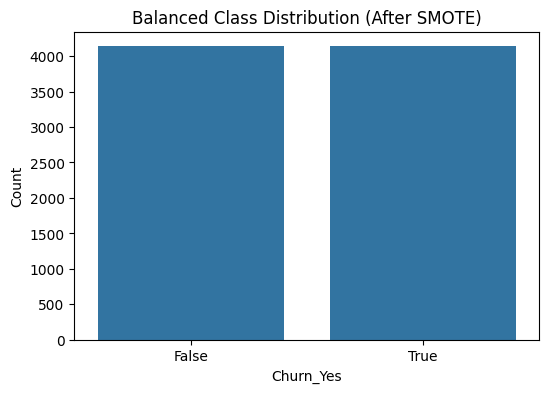

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_resampled)
plt.title('Balanced Class Distribution (After SMOTE)')
plt.xlabel('Churn_Yes')
plt.ylabel('Count')
plt.show()

Logistic Regression Performance:
Accuracy Score: 0.7367

Classification Report:
              precision    recall  f1-score   support

       False       0.88      0.74      0.81      1035
        True       0.50      0.72      0.59       374

    accuracy                           0.74      1409
   macro avg       0.69      0.73      0.70      1409
weighted avg       0.78      0.74      0.75      1409



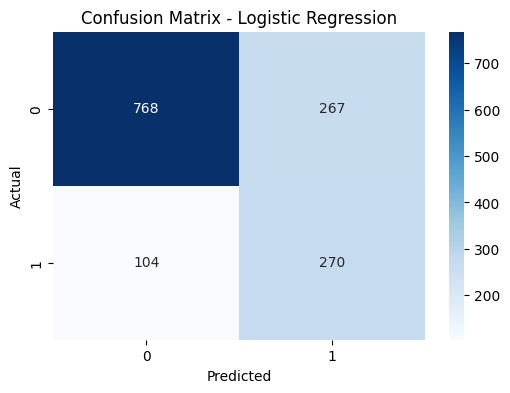

In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train_resampled, y_train_resampled)

y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression Performance:")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_log):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

K-Nearest Neighbors Performance:
Accuracy Score: 0.7140

Classification Report:
              precision    recall  f1-score   support

       False       0.87      0.71      0.79      1035
        True       0.47      0.71      0.57       374

    accuracy                           0.71      1409
   macro avg       0.67      0.71      0.68      1409
weighted avg       0.77      0.71      0.73      1409



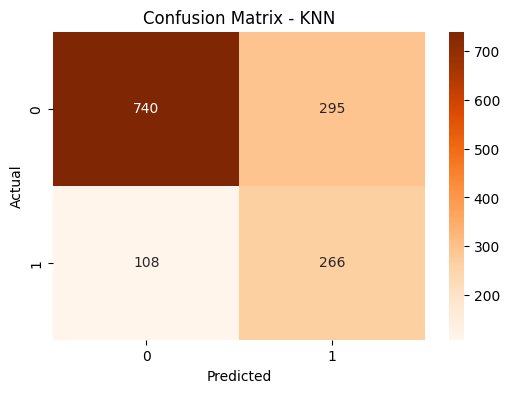

In [65]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_resampled, y_train_resampled)

y_pred_knn = knn_model.predict(X_test_scaled)

print("K-Nearest Neighbors Performance:")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_knn):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Decision Tree Performance:
Accuracy Score: 0.7026

Classification Report:
              precision    recall  f1-score   support

       False       0.82      0.76      0.79      1035
        True       0.45      0.53      0.49       374

    accuracy                           0.70      1409
   macro avg       0.63      0.65      0.64      1409
weighted avg       0.72      0.70      0.71      1409



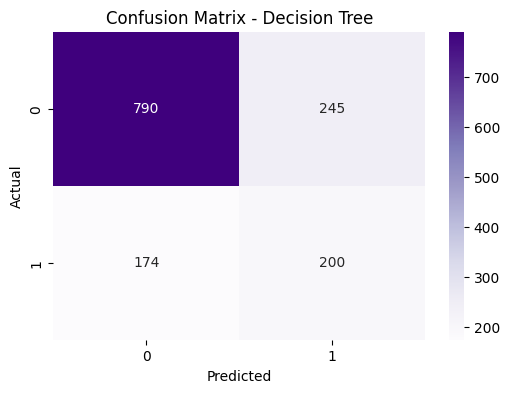

In [66]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_resampled, y_train_resampled)

y_pred_dt = dt_model.predict(X_test_scaled)

print("Decision Tree Performance:")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_dt):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

XGBoost Performance:
Accuracy Score: 0.7480

Classification Report:
              precision    recall  f1-score   support

       False       0.86      0.78      0.82      1035
        True       0.52      0.65      0.58       374

    accuracy                           0.75      1409
   macro avg       0.69      0.72      0.70      1409
weighted avg       0.77      0.75      0.76      1409



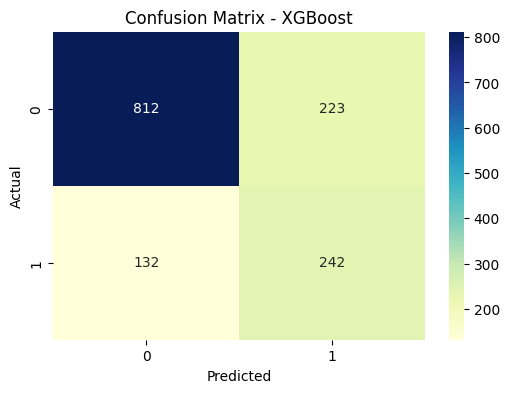

In [67]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_resampled, y_train_resampled)

y_pred_xgb = xgb_model.predict(X_test_scaled)

print("XGBoost Performance:")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_xgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='YlGnBu')
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Accuracy Score: 0.7565649396735273

Classification Report:
               precision    recall  f1-score   support

       False       0.89      0.76      0.82      1035
        True       0.53      0.75      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.76      0.77      1409



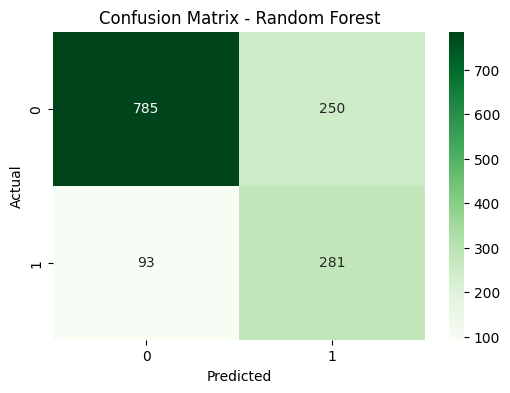


Top 10 Important Features:
 tenure                            0.174561
TotalCharges                      0.129923
Contract_Two year                 0.100156
PaymentMethod_Electronic check    0.095745
MonthlyCharges                    0.087895
InternetService_Fiber optic       0.068404
PaperlessBilling_Yes              0.046841
Contract_One year                 0.035816
OnlineSecurity_Yes                0.021211
TechSupport_Yes                   0.017714
dtype: float64


In [68]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train_resampled, y_train_resampled)
y_pred_rf = rf_model.predict(X_test_scaled)
print("Accuracy Score:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

feature_importance = pd.Series(rf_model.feature_importances_, index=X_train_resampled.columns)
print("\nTop 10 Important Features:\n", feature_importance.sort_values(ascending=False).head(10))

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'bootstrap': [True, False]
}

rf = RandomForestClassifier(random_state=42, class_weight='balanced')

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=2, scoring='f1')
grid_search.fit(X_train_resampled, y_train_resampled)

print("Best Parameters:", grid_search.best_params_)
best_rf_model = grid_search.best_estimator_

y_pred_best_rf = best_rf_model.predict(X_test_scaled)

print("\nTuned Random Forest Performance:")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_best_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_rf))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_best_rf), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Tuned Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Fitting 3 folds for each of 54 candidates, totalling 162 fits
